# OpeningGuard 統計分析流程

這份 Notebook 使用合成下單流量，檢查三種容量策略、估計不確定性，並用參數掃描說明結果是否只在單一假設下成立。所有數字都屬於 Demo 假設，不代表真實券商容量。

## 1. 載入套件與固定實驗設定

固定亂數種子，讓組員與評審能重現相同結果；RUNS 可在正式離線分析時調高。

In [1]:
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from openingguard.core import (
    compare_strategies,
    effective_worker_rps,
    generate_arrival_trace,
    load_scenario,
    simulate_trace,
)

SEED = 20260904
RUNS = 15
SCENARIO_ID = "high_pressure"
STRATEGY_LABELS = {
    "fixed_capacity": "Fixed capacity",
    "reactive_autoscaling": "Reactive autoscaling",
    "predictive_prewarm": "Predictive prewarm",
}

sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.float_format = "{:,.4f}".format
print(f"scenario={SCENARIO_ID}, runs={RUNS}, seed={SEED}")

scenario=high_pressure, runs=15, seed=20260904


## 2. 檢查情境參數

先把流量、worker、Database、交易閘道與 SLO 放在同一張表，避免把合成參數誤說成真實數據。

In [2]:
scenario = load_scenario(SCENARIO_ID)
parameter_rows = []
for group in ("traffic", "capacity", "slo", "retry"):
    for name, value in scenario[group].items():
        parameter_rows.append({"group": group, "parameter": name, "value": value})

parameter_table = pd.DataFrame(parameter_rows)
display(parameter_table)

,group,parameter,value
0,traffic,baseline_rps,260
1,traffic,scenario_multiplier,1.6000
2,traffic,open_spike_ratio,1.5500
3,traffic,decay_seconds,75
4,traffic,intensity_sigma,0.1300
5,traffic,burst_sigma,0.1800
6,capacity,current_workers,6
7,capacity,target_workers,14
8,capacity,worker_concurrency,20
9,capacity,mean_service_time_seconds,0.2000


## 3. 畫出單次開盤流量路徑

將 100 ms 到達量彙整為每秒 RPS，觀察盤初尖峰、衰減與短期群聚；這是合成 mixed-Poisson 路徑，不宣稱已配適真實交易資料。

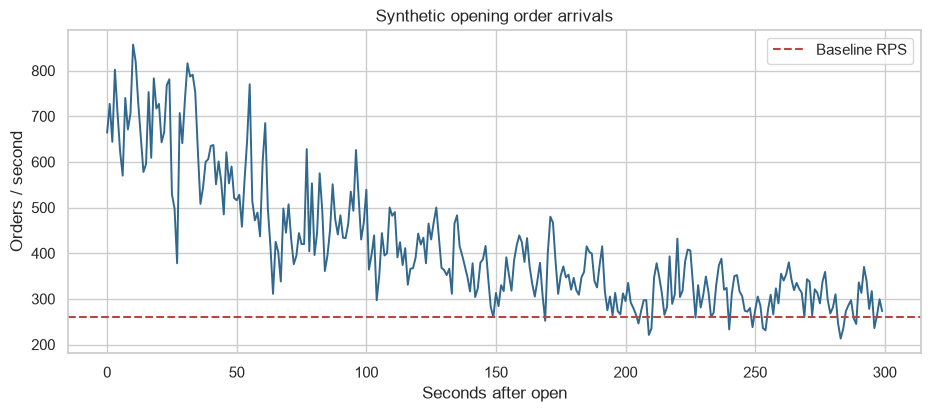

,RPS
count,300.0000
mean,415.4733
std,141.5905
min,213.0000
50%,377.0000
90%,637.4000
95%,727.1000
99%,802.1400
max,857.0000


In [3]:
arrival_trace = generate_arrival_trace(scenario, SEED)
secondly_rps = arrival_trace.reshape(-1, 10).sum(axis=1)
seconds = np.arange(len(secondly_rps))

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(seconds, secondly_rps, linewidth=1.4, color="#31688e")
ax.axhline(scenario["traffic"]["baseline_rps"], color="#b44", linestyle="--", label="Baseline RPS")
ax.set(title="Synthetic opening order arrivals", xlabel="Seconds after open", ylabel="Orders / second")
ax.legend()
plt.show()

pd.Series(secondly_rps).describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame("RPS")

## 4. 檢查不同模擬日的尖峰分布

重複生成多個開盤日，呈現 peak RPS 的經驗分布與分位數，避免只挑一條看起來漂亮的流量曲線。

,peak_rps
count,100.0000
mean,797.7500
std,130.9594
min,571.0000
50%,786.5000
90%,959.8000
95%,"1,037.0000"
99%,"1,140.2100"
max,"1,161.0000"


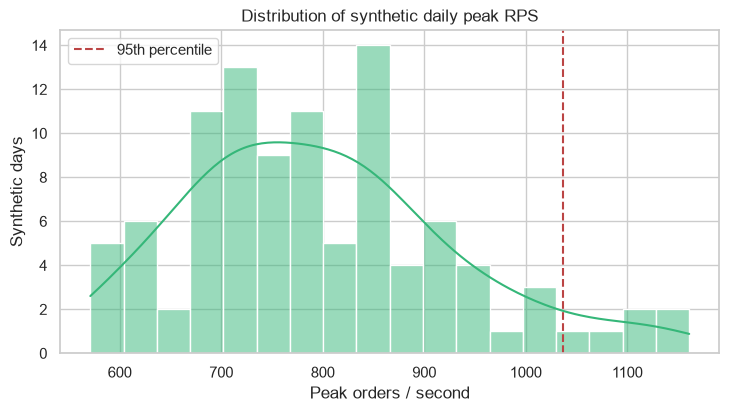

In [4]:
N_SYNTHETIC_DAYS = 100
peak_rps = []
for day in range(N_SYNTHETIC_DAYS):
    trace = generate_arrival_trace(scenario, SEED + day * 1009)
    peak_rps.append(trace.reshape(-1, 10).sum(axis=1).max())

peak_summary = pd.Series(peak_rps, name="peak_rps").describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]
)
display(peak_summary.to_frame())

fig, ax = plt.subplots(figsize=(8.5, 4.2))
sns.histplot(peak_rps, bins=18, kde=True, ax=ax, color="#35b779")
ax.axvline(np.quantile(peak_rps, 0.95), color="#b44", linestyle="--", label="95th percentile")
ax.set(title="Distribution of synthetic daily peak RPS", xlabel="Peak orders / second", ylabel="Synthetic days")
ax.legend()
plt.show()

## 5. 執行三種策略的 Monte Carlo 比較

三種策略共用同一批流量路徑，降低比較中的亂數差異；輸出壅塞機率、95% Wilson 信賴區間、延遲、逾時與 worker-minutes。

In [5]:
strategy_results = compare_strategies(scenario, runs=RUNS, seed=SEED)
results = pd.DataFrame(strategy_results)
results["strategy_label"] = results["name"].map(STRATEGY_LABELS)
results["ci_low"] = results["congestion_probability_ci95"].str[0]
results["ci_high"] = results["congestion_probability_ci95"].str[1]

display(results[[
    "strategy_label", "congestion_probability", "ci_low", "ci_high",
    "p95_latency_ms", "timeout_rate", "accepted_within_slo_rate",
    "max_queue", "database_peak_utilization", "gateway_peak_utilization",
    "total_worker_minutes",
]])

,strategy_label,congestion_probability,ci_low,ci_high,p95_latency_ms,timeout_rate,accepted_within_slo_rate,max_queue,database_peak_utilization,gateway_peak_utilization,total_worker_minutes
0,Fixed capacity,0.8667,0.6212,0.9626,"25,000.0000",0.5619,0.1854,12000,0.4000,0.4000,30.0000
1,Reactive autoscaling,0.8667,0.6212,0.9626,"14,500.0000",0.6147,0.5121,12000,0.9078,0.9078,65.6213
2,Predictive prewarm,0.0000,0.0000,0.2039,100.0000,0.0000,1.0000,117,0.8122,0.8122,70.0000


## 6. 畫出壅塞機率與信賴區間

點代表 Monte Carlo 估計值，誤差棒是 95% Wilson 區間；模擬次數少時區間較寬，因此正式報告應把 RUNS 提高。

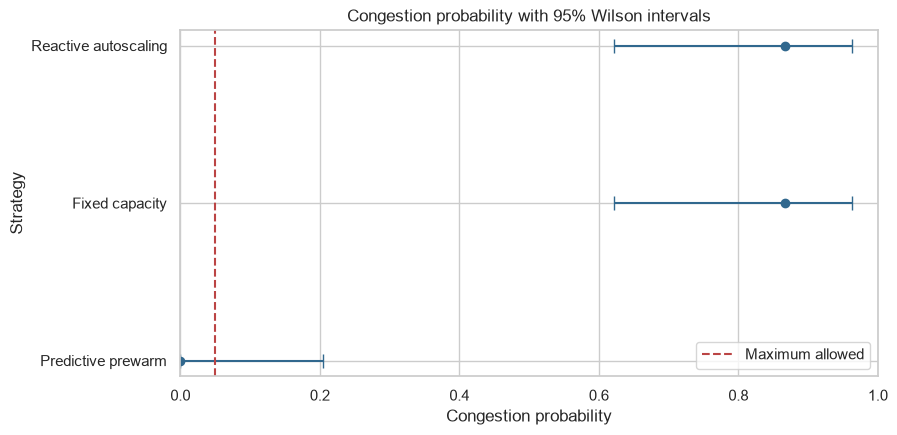

In [6]:
plot_df = results.sort_values("congestion_probability")
y = np.arange(len(plot_df))
x = plot_df["congestion_probability"].to_numpy()
xerr = np.vstack([
    x - plot_df["ci_low"].to_numpy(),
    plot_df["ci_high"].to_numpy() - x,
])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.errorbar(x, y, xerr=xerr, fmt="o", capsize=5, color="#31688e")
ax.axvline(scenario["slo"]["max_congestion_probability"], color="#b44", linestyle="--", label="Maximum allowed")
ax.set_yticks(y, plot_df["strategy_label"])
ax.set(xlim=(0, 1), xlabel="Congestion probability", ylabel="Strategy", title="Congestion probability with 95% Wilson intervals")
ax.legend()
plt.show()

## 7. 比較延遲是否低於 2 秒 SLO

以每種策略的模擬 p95 延遲對照 SLO；紅色虛線是事先定義的門檻，不是看完結果才選的界線。

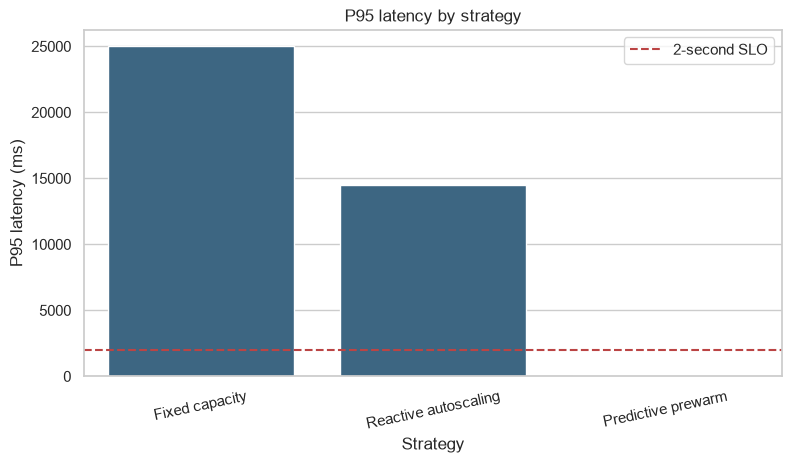

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=results, x="strategy_label", y="p95_latency_ms", ax=ax, color="#31688e")
ax.axhline(scenario["slo"]["latency_seconds"] * 1000, color="#b44", linestyle="--", label="2-second SLO")
ax.set(title="P95 latency by strategy", xlabel="Strategy", ylabel="P95 latency (ms)")
ax.tick_params(axis="x", rotation=12)
ax.legend()
plt.show()

## 8. 比較成本與服務水準

worker-minutes 是 Demo 的相對成本指標；圖中同時呈現成本與 SLO 內接受率，避免只用更多資源換取漂亮結果卻不談代價。

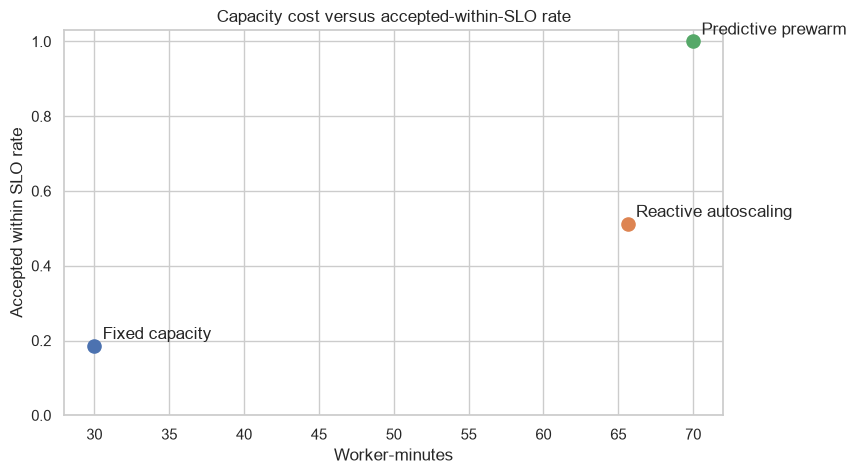

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5))
for _, row in results.iterrows():
    ax.scatter(row["total_worker_minutes"], row["accepted_within_slo_rate"], s=90)
    ax.annotate(row["strategy_label"], (row["total_worker_minutes"], row["accepted_within_slo_rate"]), xytext=(6, 5), textcoords="offset points")
ax.set(title="Capacity cost versus accepted-within-SLO rate", xlabel="Worker-minutes", ylabel="Accepted within SLO rate", ylim=(0, 1.03))
plt.show()

## 9. 掃描相對流量與 worker 數

把合成流量倍率和預熱 worker 數一起掃描，每個組合重複數次。這張證據頁用來回答「結論是否只對某一組 RPS 成立」。

In [9]:
LOAD_MULTIPLIERS = [0.8, 1.0, 1.2, 1.4]
WORKER_COUNTS = [6, 8, 10, 12, 14, 16]
SWEEP_RUNS = 3
sweep_rows = []

for load_multiplier in LOAD_MULTIPLIERS:
    for workers in WORKER_COUNTS:
        candidate = deepcopy(scenario)
        candidate["traffic"]["scenario_multiplier"] *= load_multiplier
        candidate["capacity"]["target_workers"] = workers
        congested = []
        for run_index in range(SWEEP_RUNS):
            trace_seed = SEED + run_index * 1009
            trace = generate_arrival_trace(candidate, trace_seed)
            result = simulate_trace(candidate, trace, "predictive_prewarm", trace_seed + 500_000)
            congested.append(result["congested"])
        sweep_rows.append({
            "relative_load": load_multiplier,
            "workers": workers,
            "congestion_probability": np.mean(congested),
        })

sweep = pd.DataFrame(sweep_rows)
display(sweep.head(12))

,relative_load,workers,congestion_probability
0,0.8000,6,1.0000
1,0.8000,8,0.0000
2,0.8000,10,0.0000
3,0.8000,12,0.0000
4,0.8000,14,0.0000
5,0.8000,16,0.0000
6,1.0000,6,1.0000
7,1.0000,8,0.6667
8,1.0000,10,0.0000
9,1.0000,12,0.0000


## 10. 畫出參數掃描熱圖

顏色代表壅塞機率；如果增加 worker 後仍維持高壅塞，就要繼續檢查 Database 或交易閘道，而不是宣稱 autoscaling 一定有效。

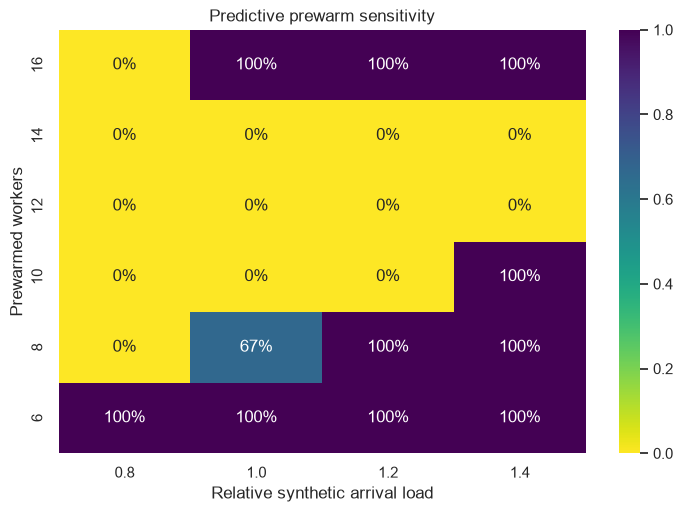

In [10]:
heatmap_data = sweep.pivot(index="workers", columns="relative_load", values="congestion_probability").sort_index(ascending=False)
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.heatmap(heatmap_data, annot=True, fmt=".0%", vmin=0, vmax=1, cmap="viridis_r", ax=ax)
ax.set(title="Predictive prewarm sensitivity", xlabel="Relative synthetic arrival load", ylabel="Prewarmed workers")
plt.show()

## 11. 證明下游硬上限

直接計算不同 worker 數的理論端到端上限。有效吞吐取 worker、Database 與交易閘道三者最小值，因此曲線進入平台後，繼續加 worker 不再改善容量。

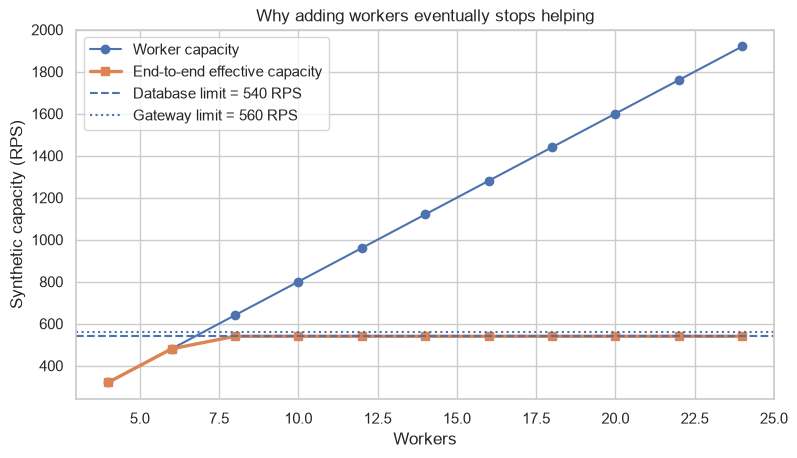

,workers,worker_capacity_rps,effective_capacity_rps
0,4,320.0000,320.0000
1,6,480.0000,480.0000
2,8,640.0000,540.0000
3,10,800.0000,540.0000
4,12,960.0000,540.0000
5,14,"1,120.0000",540.0000
6,16,"1,280.0000",540.0000
7,18,"1,440.0000",540.0000
8,20,"1,600.0000",540.0000
9,22,"1,760.0000",540.0000


In [11]:
bottleneck = load_scenario("downstream_bottleneck")
worker_grid = np.arange(4, 25, 2)
worker_capacity = worker_grid * effective_worker_rps(bottleneck["capacity"])
db_limit = bottleneck["capacity"]["db_connections"] * bottleneck["capacity"]["db_rps_per_connection"]
gateway_limit = bottleneck["capacity"]["gateway_rps"]
effective_capacity = np.minimum.reduce([
    worker_capacity,
    np.full_like(worker_capacity, db_limit),
    np.full_like(worker_capacity, gateway_limit),
])

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(worker_grid, worker_capacity, marker="o", label="Worker capacity")
ax.plot(worker_grid, effective_capacity, marker="s", linewidth=2.4, label="End-to-end effective capacity")
ax.axhline(db_limit, linestyle="--", label=f"Database limit = {db_limit} RPS")
ax.axhline(gateway_limit, linestyle=":", label=f"Gateway limit = {gateway_limit} RPS")
ax.set(title="Why adding workers eventually stops helping", xlabel="Workers", ylabel="Synthetic capacity (RPS)")
ax.legend()
plt.show()

pd.DataFrame({"workers": worker_grid, "worker_capacity_rps": worker_capacity, "effective_capacity_rps": effective_capacity})

## 12. 產生可引用的摘要表

最後整理策略比較與參數掃描結果。報告時應同時揭露 seed、runs、合成假設及信賴區間，不能把模擬輸出稱為真實券商容量。

In [12]:
summary_table = results[[
    "strategy_label", "congestion_probability", "ci_low", "ci_high",
    "p95_latency_ms", "timeout_rate", "total_worker_minutes",
]].copy()
summary_table.columns = [
    "strategy", "congestion_probability", "ci95_low", "ci95_high",
    "p95_latency_ms", "timeout_rate", "worker_minutes",
]
display(summary_table)

print("Interpretation boundary: synthetic scenario only; human approval is still required.")

,strategy,congestion_probability,ci95_low,ci95_high,p95_latency_ms,timeout_rate,worker_minutes
0,Fixed capacity,0.8667,0.6212,0.9626,"25,000.0000",0.5619,30.0000
1,Reactive autoscaling,0.8667,0.6212,0.9626,"14,500.0000",0.6147,65.6213
2,Predictive prewarm,0.0000,0.0000,0.2039,100.0000,0.0000,70.0000


Interpretation boundary: synthetic scenario only; human approval is still required.


## 13. 檢查本機 Mock 下單校準結果

讀取 calibration_results/latest.json，比較 offered concurrency 的吞吐與效率衰減，並檢查不同目標 RPS 下的 P95。這些結果只代表同一台電腦上的三階段 mock endpoint。

,offered_concurrency,throughput_rps,mean_server_ms,p95_server_ms,offered_concurrency_efficiency
0,5,21.0681,218.9964,325.2139,0.8320
1,10,41.7996,218.4993,317.6377,0.8341
2,20,80.7644,217.3097,312.1018,0.8040
3,40,81.7560,419.1968,545.0539,0.4133


,target_rps,throughput_rps,p95_end_to_end_ms,p95_queue_wait_ms,completion_throughput_ratio
0,20,19.0795,311.5301,0.0050,0.9540
1,40,36.8978,346.3936,0.0050,0.9224
2,60,54.6467,347.6015,0.0040,0.9108
3,80,74.7558,336.2860,46.3491,0.9344
4,100,83.0954,579.9026,325.8371,0.8310
5,120,84.6084,"1,124.4761",854.5962,0.7051
6,160,87.4694,"2,097.3412",882.6240,0.5467
7,200,89.3396,"2,188.0357",900.9158,0.4467


Maximum stable target RPS: 80


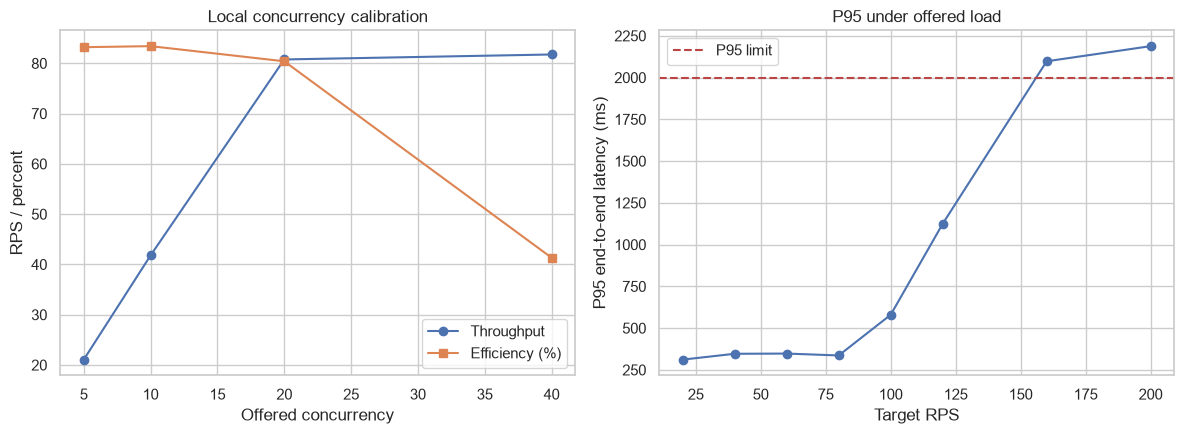

In [13]:
import json
from pathlib import Path

calibration_path = next(
    path for path in (
        Path("calibration_results/latest.json"),
        Path("../calibration_results/latest.json"),
    ) if path.exists()
)
calibration = json.loads(calibration_path.read_text(encoding="utf-8"))
concurrency_df = pd.DataFrame(calibration["concurrency_sweep"])
rate_df = pd.DataFrame(calibration["rate_sweep"])

display(concurrency_df[[
    "offered_concurrency", "throughput_rps", "mean_server_ms",
    "p95_server_ms", "offered_concurrency_efficiency",
]])
display(rate_df[[
    "target_rps", "throughput_rps", "p95_end_to_end_ms",
    "p95_queue_wait_ms", "completion_throughput_ratio",
]])
print("Maximum stable target RPS:", calibration["max_stable_target_rps"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(concurrency_df["offered_concurrency"], concurrency_df["throughput_rps"], marker="o", label="Throughput")
axes[0].plot(concurrency_df["offered_concurrency"], concurrency_df["offered_concurrency_efficiency"] * 100, marker="s", label="Efficiency (%)")
axes[0].set(title="Local concurrency calibration", xlabel="Offered concurrency", ylabel="RPS / percent")
axes[0].legend()

axes[1].plot(rate_df["target_rps"], rate_df["p95_end_to_end_ms"], marker="o")
axes[1].axhline(calibration["acceptance_rule"]["p95_end_to_end_ms_below"], color="#b44", linestyle="--", label="P95 limit")
axes[1].set(title="P95 under offered load", xlabel="Target RPS", ylabel="P95 end-to-end latency (ms)")
axes[1].legend()
plt.tight_layout()
plt.show()

## 解讀限制

- 目前沒有真實券商下單資料，因此不能宣稱到達率符合特定分布。
- mixed-Poisson、倍率、worker 吞吐、DB 與閘道容量均為可替換的合成假設。
- 小型 Monte Carlo 適合 Demo；正式圖表應提高 runs，並報告運算時間與信賴區間。
- Hawkes process 可在取得逐筆事件時間後作為未來優化與配適比較。